# Galaxy10 DECals — Station 3: Knowledge Distillation (Student-Training)

## Voraussetzung
Dieses Notebook setzt voraus, dass `milestone-3-part1-teacher.ipynb` bereits ausgeführt
wurde und die Teacher-Logits als `.npy`-Dateien vorliegen:
- `teacher_train_logits.npy`
- `teacher_val_logits.npy`

## Methodik: Offline Knowledge Distillation
Der Teacher (Zoobot ConvNeXt-Nano, ~89% Acc.) ist eingefroren. Seine **Soft-Labels**
(temperaturgewichtete Wahrscheinlichkeitsverteilungen) werden als Lehr-Signal für
7 kompakte Student-Modelle (S1–S7, 64k–2.03M Parameter) verwendet.

### Distillation-Loss
```
```
- **T (Temperature)**: Glättet die Teacher-Verteilung → enthüllt Ähnlichkeiten zwischen Klassen
- **α (Alpha)**: Gewicht der Hard-Label-Loss. Kleines α = mehr Distillation-Signal.

## Table of Contents
1. [Setup & Konfiguration](#1-setup)
2. [Daten & Logits laden](#2-daten)
3. [Distiller-Klasse](#3-distiller)
4. [Student-Training](#4-training)
5. [Evaluation & Vergleich](#5-evaluation)

## 1. Setup & Konfiguration <a id='1-setup'></a>

In [1]:
import json
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import confusion_matrix

# GPU-Initialisierung
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
            print(f"GPU initialisiert: {gpu.name}")
        except RuntimeError as e:
            print(e)
else:
    print("[WARNUNG] Keine GPU gefunden — läuft auf CPU.")

print(f"TensorFlow {tf.__version__} | GPUs: {len(gpus)}")

2026-06-30 10:34:59.623202: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-30 10:34:59.774836: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-30 10:34:59.775925: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-30 10:35:00.005968: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-30 10:35:01.174326: W tensorflow/compiler/tf

GPU initialisiert: /physical_device:GPU:0
TensorFlow 2.16.2 | GPUs: 1


2026-06-30 10:35:02.380731: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-30 10:35:02.615883: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-30 10:35:02.615960: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.


In [2]:
from data      import load_data, prepare_splits, NUM_CLASSES, LABEL_DICT
from models_kd import STUDENT_VARIANTS, build_student_model

# ── Pfade ────────────────────────────────────────────────────────────────────
DATA_PATH        = './../data/Galaxy10_DECals.h5'
REPORTS_DIR      = Path('./../reports/knowledge_distillation')
LOGS_BASE_DIR    = Path('./../logs/knowledge_distillation')
CHECKPOINT_DIR   = LOGS_BASE_DIR / 'checkpoints'

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_BASE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ── Hyperparameter ───────────────────────────────────────────────────────────
BATCH_SIZE  = 32
EPOCHS      = 100
TEMPERATURE = 5.0    # T: höher → weichere Verteilung → mehr Klassen-Ähnlichkeiten sichtbar
ALPHA       = 0.1    # Anteil Hard-Label-Loss; 0.1 = 90% Distillation, 10% CE
LR          = 1e-3   # Lernrate für den Distiller-Optimizer

# Welche Studenten trainieren?
# None = alle | oder z.B. ["S4_Base", "S5_Large", "S6_XL", "S7_Max"] für schnelle Tests
TRAIN_ONLY: list[str] | None = None

# Bereits trainierte Studenten laden statt neu trainieren?
LOAD_CHECKPOINTS = False

print("Konfiguration geladen.")
print(f"  Temperature T = {TEMPERATURE}  |  Alpha α = {ALPHA}")
print(f"  Epochen = {EPOCHS}  |  Batch = {BATCH_SIZE}  |  LR = {LR}")

2026-06-30 10:35:02.693795: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.


Konfiguration geladen.
  Temperature T = 5.0  |  Alpha α = 0.1
  Epochen = 100  |  Batch = 32  |  LR = 0.001


2026-06-30 10:35:02.693921: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-30 10:35:02.693976: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-30 10:35:02.930594: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-30 10:35:02.930673: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:2d:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-30 10:35:02.930683: I tensorflow/core/common_runtime/gpu/gpu

## 2. Daten & Logits laden <a id='2-daten'></a>

**Wichtig:** `random_state=42` und `use_kfold=False` müssen exakt mit Part 1 übereinstimmen,
damit die gespeicherten Logits denselben Samples entsprechen wie der Train/Val-Split hier.

In [3]:
print("Lade Bilder...")
images_raw, labels = load_data(DATA_PATH)

# Identischer Split wie in Part 1 (Teacher-Inferenz)
split_folds, X_test, y_test = prepare_splits(
    labels, use_kfold=False, val_size=0.2, test_size=0.2, random_state=42
)
train_idx, val_idx = split_folds[0]
print(f"Split: Train {len(train_idx):,} | Val {len(val_idx):,} | Test {len(X_test):,}")

print("\nLade Teacher-Logits...")
train_logits = np.load('teacher_train_logits.npy')
val_logits   = np.load('teacher_val_logits.npy')

# Sanity-Check: Logits müssen zum Split passen
assert len(train_idx) == len(train_logits), (
    f"FEHLER: {len(train_idx)} Train-Samples, aber {len(train_logits)} Logits! "
    "Bitte Part 1 mit denselben Split-Parametern neu ausführen."
)
assert len(val_idx) == len(val_logits), (
    f"FEHLER: {len(val_idx)} Val-Samples, aber {len(val_logits)} Logits!"
)

print(f"Teacher-Logits verifiziert: Train {train_logits.shape} | Val {val_logits.shape}")

Lade Bilder...
Dataset geladen: 17,736 Bilder, Shape (17736, 256, 256, 3)

Split-Modus : Einfacher Train/Val-Split
Train + Val : 14,188 Samples
Test        : 3,548 Samples
  Train 11,350 | Val 2,838
Split: Train 11,350 | Val 2,838 | Test 3,548

Lade Teacher-Logits...
Teacher-Logits verifiziert: Train (11350, 10) | Val (2838, 10)


In [4]:
def prepare_tf_dataset(
    indices: np.ndarray,
    teacher_logits: np.ndarray,
    batch_size: int,
    is_training: bool = True,
) -> tf.data.Dataset:
    """
    Erstellt ein tf.data.Dataset mit (Bild, Label, Teacher-Logits) als Tripel.

    WICHTIG — RAM-schonende Variante (analog zu RAMDataGenerator aus Station 1):
    Wir bauen das Dataset NICHT aus einer komplett vor-normalisierten float32-Kopie
    von images_raw[indices] (das hätte bei ~14k Bildern à 256x256x3 ca. 11 GB
    RAM allein für den Train-Split gekostet -> OOM-Crash unter WSL!).

    Stattdessen liegt im Dataset nur ein kleines Array aus *Positionen*
    (0 .. len(indices)-1). Für jeden Batch wird per tf.py_function erst zur
    Laufzeit der passende Ausschnitt aus images_raw (uint8) geholt und NUR
    dieser kleine Batch nach float32 konvertiert + normalisiert. Das hält den
    RAM-Verbrauch konstant niedrig, unabhängig von der Datensatzgröße.

    Normalisierung: uint8 [0,255] -> float32 [0.0,1.0]
    Die Augmentierung passiert weiterhin innerhalb des Student-Modells
    (Keras-Layer), nicht hier im Dataset -- konsistent mit Station 1 & 2.
    """

    def gather_batch(batch_positions: np.ndarray):
        # batch_positions sind Positionen *innerhalb* von `indices`/`teacher_logits`
        batch_positions = batch_positions.numpy()
        abs_indices = indices[batch_positions]

        # Nur dieser kleine Batch wird kopiert + normalisiert (wie im RAMDataGenerator)
        x_batch = images_raw[abs_indices].astype(np.float32) / 255.0
        y_batch = labels[abs_indices]
        t_batch = teacher_logits[batch_positions]

        return x_batch, y_batch, t_batch

    def tf_gather_batch(batch_positions):
        x, y, t = tf.py_function(
            func=gather_batch,
            inp=[batch_positions],
            Tout=[tf.float32, tf.int64, tf.float32],
        )
        x.set_shape([None, *images_raw.shape[1:]])
        y.set_shape([None])
        t.set_shape([None, NUM_CLASSES])
        return x, y, t

    # Dataset aus reinen Positionsindizes (winzig, kein Speicherproblem)
    positions = np.arange(len(indices))
    pos_dataset = tf.data.Dataset.from_tensor_slices(positions)

    if is_training:
        pos_dataset = pos_dataset.shuffle(buffer_size=len(indices), seed=42)

    pos_dataset = pos_dataset.batch(batch_size, drop_remainder=False)
    dataset = pos_dataset.map(tf_gather_batch, num_parallel_calls=tf.data.AUTOTUNE)

    return dataset.prefetch(tf.data.AUTOTUNE)


train_dataset = prepare_tf_dataset(train_idx, train_logits, BATCH_SIZE, is_training=True)
val_dataset   = prepare_tf_dataset(val_idx,   val_logits,   BATCH_SIZE, is_training=False)
print("tf.data.Datasets erstellt (RAM-schonend, Batch-weise Normalisierung).")


tf.data.Datasets erstellt (RAM-schonend, Batch-weise Normalisierung).


## 3. Distiller-Klasse <a id='3-distiller'></a>

Die `train_step`-Methode kombiniert:
- **Hard-Loss** `L_CE`: Student-Logits vs. echte Labels (One-Hot)
- **Soft-Loss** `L_KL`: Temperatur-geglättete Teacher-Probs vs. Student-Probs

In [ ]:
class Distiller(keras.Model):
    """
    Knowledge Distillation nach Hinton et al. (2015).

    Erwartet Batches der Form (x, y_hard, teacher_logits).
    Der Student muss Logits ausgeben (kein Softmax!),
    was durch build_student_model() aus models_kd.py sichergestellt wird.

    Loss-Formel:
        L = α · L_CE(y, z_s) + (1-α) · L_KL(softmax(z_t/T) ‖ softmax(z_s/T))
    """

    def __init__(self, student: keras.Model, temperature: float = 5.0, alpha: float = 0.1):
        super().__init__()
        self.student         = student
        self.temperature     = temperature
        self.alpha           = alpha
        self.student_loss_fn = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
        self.distill_loss_fn = keras.losses.KLDivergence()  # KL(teacher ‖ student)

        # Metriken — werden automatisch von Keras pro Epoche geloggt
        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.acc_tracker        = keras.metrics.SparseCategoricalAccuracy(name="accuracy")
        self.ce_loss_tracker    = keras.metrics.Mean(name="ce_loss")
        self.kd_loss_tracker    = keras.metrics.Mean(name="kd_loss")

    def call(self, x):
        """Weiterleitung an den Student (nötig für model.predict())."""
        return self.student(x)

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.acc_tracker,
                self.ce_loss_tracker,    self.kd_loss_tracker]

    def train_step(self, data):
        x, y_hard, teacher_logits = data

        with tf.GradientTape() as tape:
            student_logits = self.student(x, training=True)

            # ── Hard-Label-Loss (Cross-Entropy mit echten Labels) ────────────
            ce_loss = self.student_loss_fn(y_hard, student_logits)

            # ── Soft-Label-Loss (KL-Divergenz mit Temperature-Scaling) ───────
            soft_teacher = tf.nn.softmax(teacher_logits  / self.temperature, axis=-1)
            soft_student = tf.nn.softmax(student_logits  / self.temperature, axis=-1)
            kd_loss      = self.distill_loss_fn(soft_teacher, soft_student)

            # ── Kombinierter Loss (Formel aus der Vorlesung: Folie 68) ──────────
            # L_total = α · L_student + (1-α) · L_distillation
            loss = (
                self.alpha * ce_loss
                + (1.0 - self.alpha) * kd_loss
            )

        gradients = tape.gradient(loss, self.student.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.student.trainable_variables))

        self.total_loss_tracker.update_state(loss)
        self.acc_tracker.update_state(y_hard, student_logits)
        self.ce_loss_tracker.update_state(ce_loss)
        self.kd_loss_tracker.update_state(kd_loss)

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        """Validation: Nur CE-Loss (keine Teacher-Logits nötig für Bewertung)."""
        x, y_hard, _ = data
        student_logits = self.student(x, training=False)
        ce_loss        = self.student_loss_fn(y_hard, student_logits)

        self.total_loss_tracker.update_state(ce_loss)
        self.acc_tracker.update_state(y_hard, student_logits)
        self.ce_loss_tracker.update_state(ce_loss)

        return {m.name: m.result() for m in self.metrics
                if m.name != "kd_loss"}


print("Distiller-Klasse definiert.")

Distiller-Klasse definiert.


## 4. Student-Training <a id='4-training'></a>

Alle 7 Studenten werden nacheinander trainiert. Pro Student:
1. Frisches Modell via `build_student_model()` (garantiert keine geteilten Gewichte)
2. `Distiller` wrapping
3. EarlyStopping + ReduceLROnPlateau + ModelCheckpoint

In [6]:
# Filtere Varianten falls TRAIN_ONLY gesetzt
active_variants = {
    k: v for k, v in STUDENT_VARIANTS.items()
    if TRAIN_ONLY is None or k in TRAIN_ONLY
}

print(f"Zu trainieren: {len(active_variants)} Student(en)")
for name, (model_obj, approx_params) in active_variants.items():
    model_obj.build((None, 256, 256, 3))
    exact = model_obj.count_params()
    print(f"  {name:12s} ({approx_params:>7s})  →  exakt {exact:>10,} Parameter")

Zu trainieren: 7 Student(en)
  S1_Nano      (   ~64k)  →  exakt     63,626 Parameter
  S2_Small     (  ~251k)  →  exakt    251,146 Parameter
  S3_Medium    (  ~619k)  →  exakt    619,178 Parameter
  S4_Base      ( ~1.10M)  →  exakt  1,096,362 Parameter
  S5_Large     ( ~1.24M)  →  exakt  1,244,458 Parameter
  S6_XL        ( ~1.84M)  →  exakt  1,835,562 Parameter
  S7_Max       ( ~2.03M)  →  exakt  2,032,682 Parameter


In [7]:
trained_students  = {}   # name → keras.Model (Student-Modell nach Training)
training_histories = {}  # name → History-Objekt

print("=" * 65)
print("STARTE KNOWLEDGE DISTILLATION")
print(f"Teacher: Zoobot ConvNeXt-Nano (~89% Test-Accuracy)")
print(f"T={TEMPERATURE}  α={ALPHA}  Epochen={EPOCHS}  Batch={BATCH_SIZE}")
print("=" * 65)

for variant_name, (architecture, approx_params) in active_variants.items():
    print(f"\n{'='*65}")
    print(f"Student: {variant_name} ({approx_params})")
    print(f"{'='*65}")

    timestamp = datetime.now().strftime("%Y%m%d-%H%M%S")
    safe_name = variant_name.replace(' ', '_')
    ckpt_path = CHECKPOINT_DIR / f"{safe_name}_{timestamp}.weights.h5"

    # Checkpoint vorhanden und LOAD_CHECKPOINTS aktiv?
    existing_ckpts = sorted(CHECKPOINT_DIR.glob(f"{safe_name}_*.weights.h5"))
    if LOAD_CHECKPOINTS and existing_ckpts:
        latest_ckpt = existing_ckpts[-1]
        print(f"  Lade Checkpoint: {latest_ckpt.name}")
        student_model = build_student_model(architecture, learning_rate=LR)
        student_model.build((None, 256, 256, 3))
        student_model.load_weights(str(latest_ckpt))
        trained_students[variant_name]   = student_model
        training_histories[variant_name] = None
        print(f"  Checkpoint geladen.")
        continue

    # Frisches Student-Modell (build_student_model klont architecture intern)
    student_model = build_student_model(architecture, learning_rate=LR)

    # Distiller aufbauen und kompilieren
    distiller = Distiller(
        student=student_model,
        temperature=TEMPERATURE,
        alpha=ALPHA,
    )
    distiller.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
    )
    distiller.build((None, 256, 256, 3))

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=8,
            restore_best_weights=True,
            verbose=1,
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            verbose=1,
        ),
        keras.callbacks.ModelCheckpoint(
            filepath=str(ckpt_path),
            save_weights_only=True,
            save_best_only=True,
            monitor='val_loss',
            verbose=0,
        ),
        keras.callbacks.TensorBoard(
            log_dir=str(LOGS_BASE_DIR / f"{safe_name}_{timestamp}"),
        ),
    ]

    history = distiller.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    trained_students[variant_name]   = student_model
    training_histories[variant_name] = history
    print(f"  Checkpoint gespeichert: {ckpt_path.name}")

print(f"\n{'='*65}")
print("Alle Studenten trainiert!")

STARTE KNOWLEDGE DISTILLATION
Teacher: Zoobot ConvNeXt-Nano (~89% Test-Accuracy)
T=5.0  α=0.1  Epochen=100  Batch=32

Student: S1_Nano (~64k)
Epoch 1/100


2026-06-30 10:35:49.889774: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


355/355 ━━━━━━━━━━━━━━━━━━━━ 41s 93ms/step - accuracy: 0.3009 - ce_loss: 1.9311 - kd_loss: 0.3150 - loss: 0.4766 - val_accuracy: 0.1142 - val_ce_loss: 2.9524 - val_loss: 2.9524 - learning_rate: 0.0010
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.4037 - ce_loss: 1.6570 - kd_loss: 0.2537 - loss: 0.3940 - val_accuracy: 0.2153 - val_ce_loss: 3.1948 - val_loss: 3.1948 - learning_rate: 0.0010
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.4895 - ce_loss: 1.4451 - kd_loss: 0.2112 - loss: 0.3346 - val_accuracy: 0.2713 - val_ce_loss: 2.7866 - val_loss: 2.7866 - learning_rate: 0.0010
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 33s 90ms/step - accuracy: 0.5558 - ce_loss: 1.2916 - kd_loss: 0.1839 - loss: 0.2946 - val_accuracy: 0.3911 - val_ce_loss: 1.9218 - val_loss: 1.9218 - learning_rate: 0.0010
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.6007 - ce_loss: 1.1557 - kd_loss: 0.1609 - loss: 0.2604 - val_accuracy: 0.4813 - val_ce_los

2026-06-30 11:03:34.620362: W external/local_tsl/tsl/framework/bfc_allocator.cc:368] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


355/355 ━━━━━━━━━━━━━━━━━━━━ 54s 136ms/step - accuracy: 0.3298 - ce_loss: 1.8653 - kd_loss: 0.2965 - loss: 0.4534 - val_accuracy: 0.1959 - val_ce_loss: 2.6332 - val_loss: 2.6332 - learning_rate: 0.0010
Epoch 2/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 48s 133ms/step - accuracy: 0.4325 - ce_loss: 1.6012 - kd_loss: 0.2353 - loss: 0.3719 - val_accuracy: 0.3372 - val_ce_loss: 2.2853 - val_loss: 2.2853 - learning_rate: 0.0010
Epoch 3/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 48s 135ms/step - accuracy: 0.5159 - ce_loss: 1.3716 - kd_loss: 0.1954 - loss: 0.3130 - val_accuracy: 0.3485 - val_ce_loss: 2.3699 - val_loss: 2.3699 - learning_rate: 0.0010
Epoch 4/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 48s 134ms/step - accuracy: 0.5817 - ce_loss: 1.2113 - kd_loss: 0.1662 - loss: 0.2707 - val_accuracy: 0.3548 - val_ce_loss: 2.0037 - val_loss: 2.0037 - learning_rate: 0.0010
Epoch 5/100
355/355 ━━━━━━━━━━━━━━━━━━━━ 48s 133ms/step - accuracy: 0.6197 - ce_loss: 1.1049 - kd_loss: 0.1458 - loss: 0.2417 - val_accuracy: 0.5194 - val_c

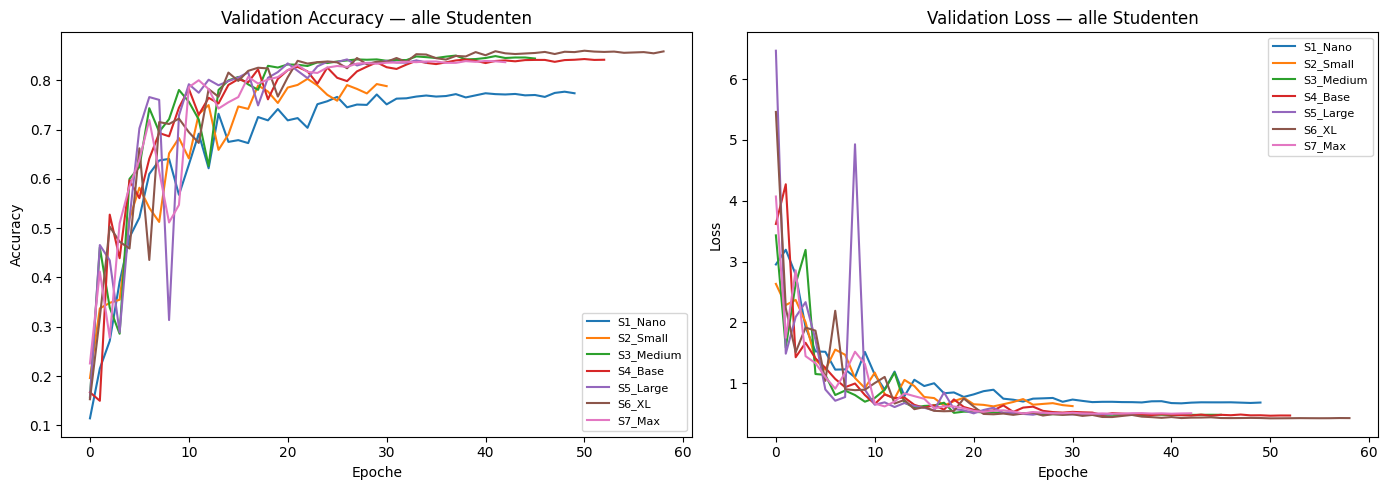

Trainings-Kurven gespeichert: ../reports/knowledge_distillation/training_curves_all_students.png


In [8]:
# Trainings-Kurven für alle Studenten (überspringt geladene Checkpoints)
valid_histories = [
    (name, h) for name, h in training_histories.items() if h is not None
]

if valid_histories:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for name, history in valid_histories:
        axes[0].plot(history.history['val_accuracy'], label=name)
        axes[1].plot(history.history['val_loss'],     label=name)

    axes[0].set_title('Validation Accuracy — alle Studenten')
    axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(fontsize=8)

    axes[1].set_title('Validation Loss — alle Studenten')
    axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Loss')
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    curves_path = REPORTS_DIR / 'training_curves_all_students.png'
    plt.savefig(curves_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Trainings-Kurven gespeichert: {curves_path}")
else:
    print("Alle Modelle wurden aus Checkpoints geladen — keine Kurven verfügbar.")

## 5. Evaluation & Vergleich <a id='5-evaluation'></a>

Jeder Student wird auf dem **fixen Test-Set** ausgewertet, das in allen drei Stationen
identisch ist. Anschließend werden die Ergebnisse mit Station 1 (eigene CNNs) und
Station 2 (Transfer Learning) verglichen.

In [9]:
# Test-Set als Dataset (nur Bilder, keine Logits nötig)
# RAM-schonend: wie bei prepare_tf_dataset() keine eager float32-Kopie
# des kompletten Test-Splits, sondern Batch-weise Normalisierung.
def gather_test_batch(batch_positions: np.ndarray):
    batch_positions = batch_positions.numpy()
    abs_indices = X_test[batch_positions]
    return images_raw[abs_indices].astype(np.float32) / 255.0

def tf_gather_test_batch(batch_positions):
    x = tf.py_function(func=gather_test_batch, inp=[batch_positions], Tout=tf.float32)
    x.set_shape([None, *images_raw.shape[1:]])
    return x

test_positions = np.arange(len(X_test))
test_dataset = (
    tf.data.Dataset.from_tensor_slices(test_positions)
    .batch(BATCH_SIZE, drop_remainder=False)
    .map(tf_gather_test_batch, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

# Ergebnisse aus Station 1 und 2 (als Referenz für den Plot)
# Format: "Anzeigename" → {"params": Mio., "acc": %, "station": int}
reference_models = {
    # Station 1 — eigene CNNs (aus architecture_ranking.csv)
    "S1: v7_five_conv_blocks (2.49M)":        {"params": 2.492, "acc": 82.36, "station": 1},
    "S1: 9_conv_layer_cnn (2.49M)":           {"params": 2.492, "acc": 82.33, "station": 1},
    "S1: v9_with_512_dense (2.76M)": {"params": 2.755, "acc": 82.27, "station": 1},
    "S1: v5_deeper_dense (685k)":    {"params": 0.685, "acc": 80.67, "station": 1},
    "S1: v6_dropout_03 (685k)":      {"params": 0.685, "acc": 78.69, "station": 1},
    "S1: v4_deeper_filters (619k)":  {"params": 0.619, "acc": 75.14, "station": 1},
    "S1: v3_double_conv (298k)":     {"params": 0.298, "acc": 70.69, "station": 1},
    "S1: v2_minimal_gap (103k)":     {"params": 0.103, "acc": 45.24, "station": 1},

    # Station 2 — Transfer Learning
    "S2: Zoobot finetuned (15.1M) [Teacher]": {"params": 15.11, "acc": 89.12, "station": 2},
    "S2: Zoobot frozen (15.1M)":              {"params": 15.11, "acc": 88.33, "station": 2},
    "S2: Inception V3 (22.5M)":               {"params": 22.54, "acc": 61.22, "station": 2},
    "S2: ResNet-152 (59.7M)":                 {"params": 59.68, "acc": 43.55, "station": 2},
    "S2: ResNet-50 (24.9M)":                  {"params": 24.89, "acc": 38.64, "station": 2},
}

# Student-Ergebnisse messen
student_results = {}
all_results     = dict(reference_models)  # wird um KD-Studenten erweitert

print("Evaluiere Studenten auf dem Test-Set...\n")
for name, model in trained_students.items():
    probs  = model.predict(test_dataset, verbose=0)
    y_pred = np.argmax(probs, axis=1)
    acc    = float(np.mean(y_pred == y_test) * 100)
    params = float(model.count_params() / 1_000_000)

    label = f"S3 KD: {name} ({params:.2f}M)"
    student_results[name] = {"acc": acc, "params": params, "label": label}
    all_results[label]    = {"params": params, "acc": acc, "station": 3}

    print(f"  {name:12s} ({params:.3f}M)  →  Test Accuracy: {acc:.2f}%")

Evaluiere Studenten auf dem Test-Set...

  S1_Nano      (0.064M)  →  Test Accuracy: 78.10%
  S2_Small     (0.251M)  →  Test Accuracy: 78.69%
  S3_Medium    (0.619M)  →  Test Accuracy: 83.99%
  S4_Base      (1.096M)  →  Test Accuracy: 84.16%
  S5_Large     (1.244M)  →  Test Accuracy: 84.19%
  S6_XL        (1.836M)  →  Test Accuracy: 85.23%
  S7_Max       (2.033M)  →  Test Accuracy: 83.34%


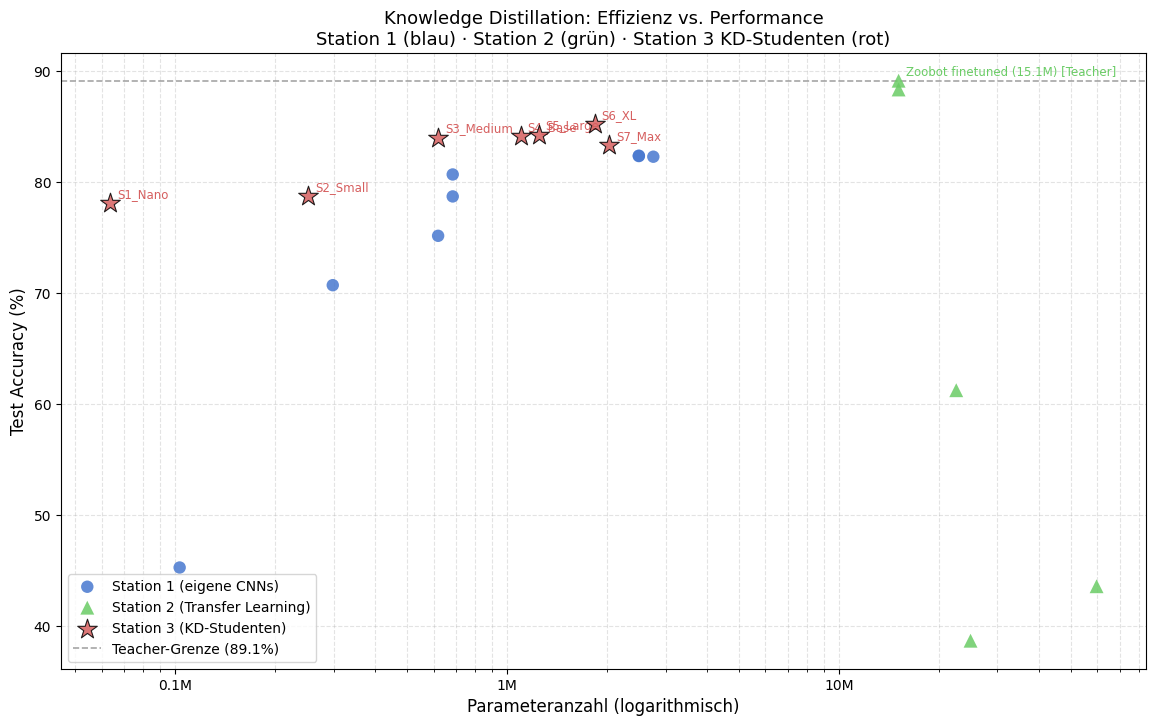

Plot gespeichert: ../reports/knowledge_distillation/params_vs_accuracy_all_stations.png


In [10]:
# ═══════════════════════════════════════════════════════════════════════
# PLOT 1: Parameter vs. Accuracy (Stationen 1, 2, 3 im Vergleich)
# ═══════════════════════════════════════════════════════════════════════

COLORS  = {1: '#4878CF', 2: '#6ACC65', 3: '#D65F5F'}  # Blau, Grün, Rot
MARKERS = {1: 'o',       2: '^',       3: '*'}
SIZES   = {1: 80,        2: 100,       3: 220}
LABELS  = {1: 'Station 1 (eigene CNNs)', 2: 'Station 2 (Transfer Learning)',
           3: 'Station 3 (KD-Studenten)'}

fig, ax = plt.subplots(figsize=(14, 8))

plotted_labels = set()
for display_name, info in all_results.items():
    s = info['station']
    legend_label = LABELS[s] if LABELS[s] not in plotted_labels else '_nolegend_'
    plotted_labels.add(LABELS[s])

    ax.scatter(
        info['params'], info['acc'],
        color=COLORS[s], marker=MARKERS[s], s=SIZES[s],
        label=legend_label, alpha=0.85, zorder=3,
        edgecolors='black' if s == 3 else 'none', linewidths=0.8,
    )

    # Text-Labels nur für KD-Studenten und Teacher
    if s == 3 or 'Teacher' in display_name:
        short = display_name.split('KD: ')[-1].split(' (')[0] if 'KD' in display_name else display_name.split(': ')[-1]
        ax.annotate(
            short,
            xy=(info['params'], info['acc']),
            xytext=(5, 4), textcoords='offset points',
            fontsize=8.5, color=COLORS[s],
        )

# Teacher-Benchmark-Linie
teacher_acc = reference_models['S2: Zoobot finetuned (15.1M) [Teacher]']['acc']
ax.axhline(teacher_acc, color='gray', linestyle='--', linewidth=1.2, alpha=0.7,
           label=f'Teacher-Grenze ({teacher_acc:.1f}%)')

ax.set_xscale('log')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:g}M'))
ax.set_xlabel('Parameteranzahl (logarithmisch)', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title(
    'Knowledge Distillation: Effizienz vs. Performance\n'
    'Station 1 (blau) · Station 2 (grün) · Station 3 KD-Studenten (rot)',
    fontsize=13
)
ax.legend(fontsize=10)
ax.grid(True, which='both', ls='--', alpha=0.35)

scatter_path = REPORTS_DIR / f'params_vs_accuracy_all_stations.png'
fig.savefig(scatter_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Plot gespeichert: {scatter_path}")

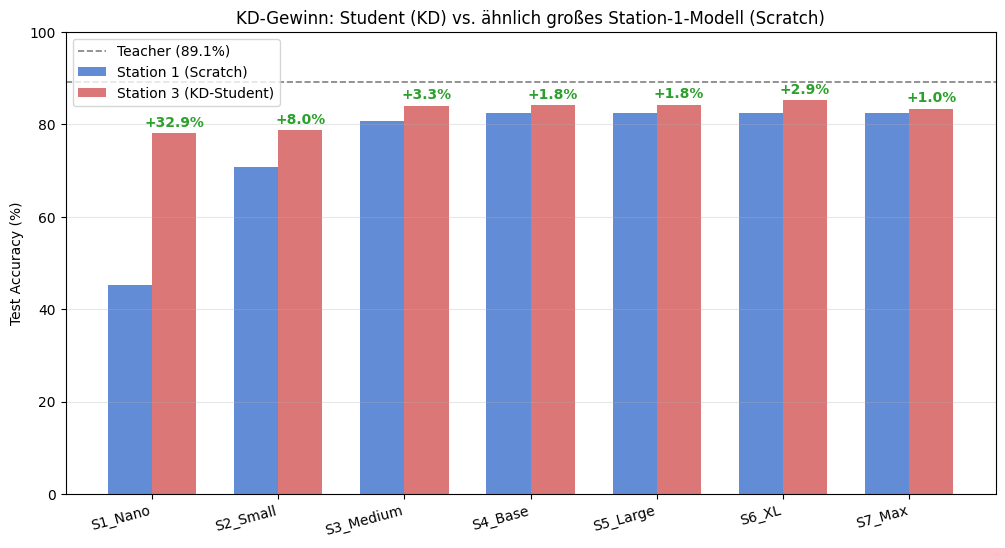

KD-Gain-Plot gespeichert: ../reports/knowledge_distillation/kd_gain_vs_scratch.png


In [11]:
# ═══════════════════════════════════════════════════════════════════════
# PLOT 2: KD-Gewinn — Student vs. vergleichbares Station-1-Modell
# Zeigt, wie viel Accuracy KD gegenüber Scratch-Training bringt
# ═══════════════════════════════════════════════════════════════════════

# Mapping: ungefähre Parameterklasse → beste Station-1-Accuracy in dem Bereich
# (manuell befüllt aus den Referenzwerten oben)
s1_by_class = {
    '~64k':  45.24,  # v2_minimal_gap
    '~251k': 70.69,  # v3_double_conv  (nächste Klasse)
    '~619k': 80.67,  # v5_deeper_dense (nächste Klasse)
    '~1.10M': 82.36, # v7 / 9_conv_layer (obere Klasse)
    '~1.24M': 82.36,
    '~1.84M': 82.36,
    '~2.03M': 82.36,
}

student_names, kd_accs, scratch_accs, gains = [], [], [], []

for variant_name, (_, approx) in active_variants.items():
    if variant_name not in student_results:
        continue
    kd_acc     = student_results[variant_name]['acc']
    scratch_acc = s1_by_class.get(approx, None)
    if scratch_acc is None:
        continue
    student_names.append(variant_name)
    kd_accs.append(kd_acc)
    scratch_accs.append(scratch_acc)
    gains.append(kd_acc - scratch_acc)

x    = np.arange(len(student_names))
w    = 0.35
fig2, ax2 = plt.subplots(figsize=(12, 6))

bars1 = ax2.bar(x - w/2, scratch_accs, w, label='Station 1 (Scratch)', color='#4878CF', alpha=0.85)
bars2 = ax2.bar(x + w/2, kd_accs,     w, label='Station 3 (KD-Student)', color='#D65F5F', alpha=0.85)

for i, gain in enumerate(gains):
    color = '#2ca02c' if gain >= 0 else '#d62728'
    ax2.annotate(
        f'{gain:+.1f}%',
        xy=(x[i] + w/2, kd_accs[i]),
        xytext=(0, 5), textcoords='offset points',
        ha='center', fontsize=10, fontweight='bold', color=color,
    )

ax2.axhline(teacher_acc, color='gray', linestyle='--', linewidth=1.2,
            label=f'Teacher ({teacher_acc:.1f}%)')
ax2.set_xticks(x)
ax2.set_xticklabels(student_names, rotation=15, ha='right')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('KD-Gewinn: Student (KD) vs. ähnlich großes Station-1-Modell (Scratch)')
ax2.legend()
ax2.set_ylim([0, 100])
ax2.grid(axis='y', alpha=0.3)

gain_path = REPORTS_DIR / 'kd_gain_vs_scratch.png'
fig2.savefig(gain_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"KD-Gain-Plot gespeichert: {gain_path}")

Bester KD-Student: S6_XL (85.23% Test-Accuracy)


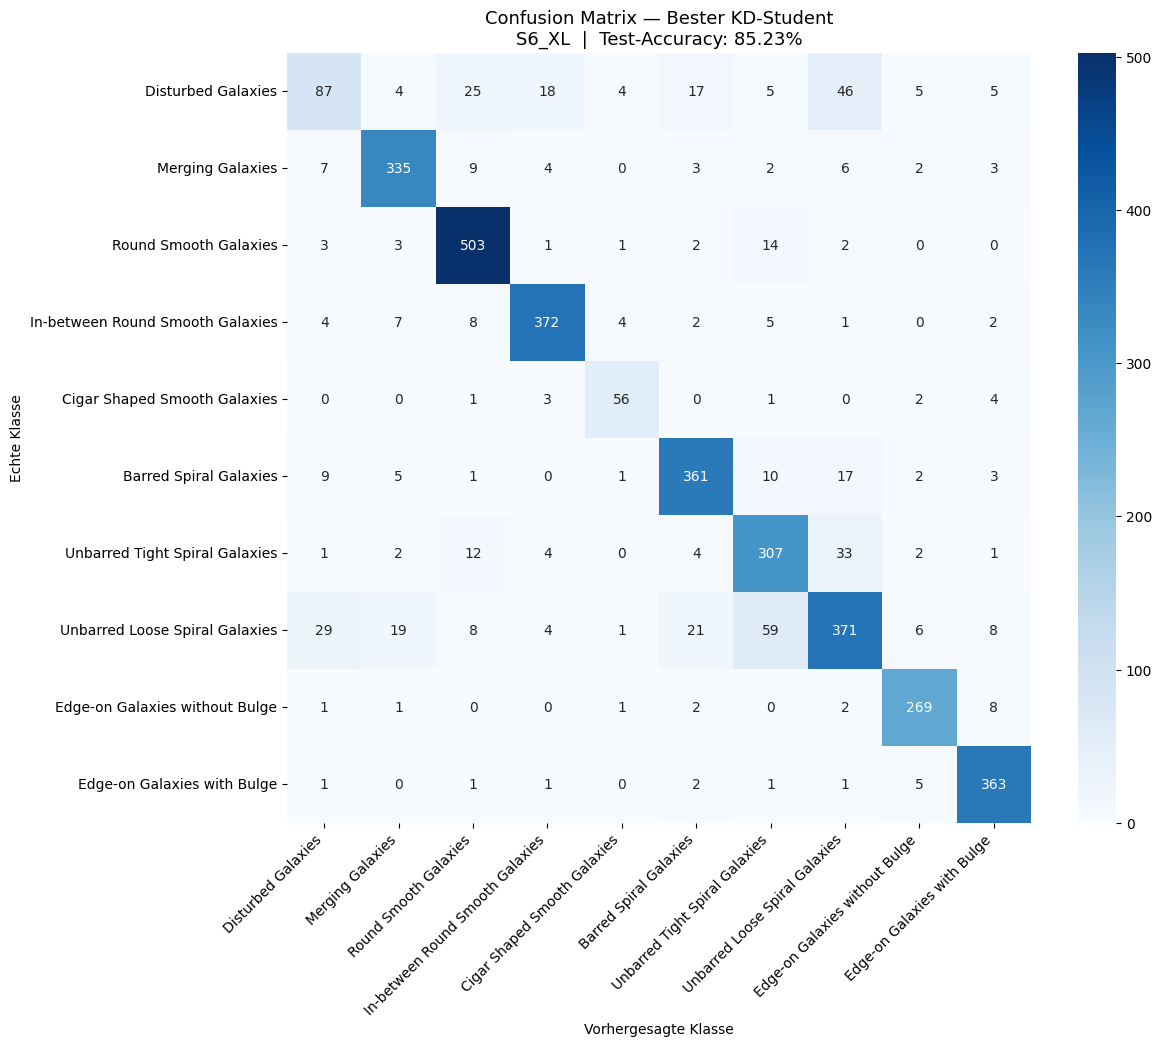

Confusion Matrix gespeichert: ../reports/knowledge_distillation/confusion_matrix_best_kd_S6_XL.png


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# PLOT 3: Confusion Matrix des besten KD-Studenten
# ═══════════════════════════════════════════════════════════════════════

best_name = max(student_results, key=lambda k: student_results[k]['acc'])
best_model = trained_students[best_name]
best_acc   = student_results[best_name]['acc']

print(f"Bester KD-Student: {best_name} ({best_acc:.2f}% Test-Accuracy)")

probs_best = best_model.predict(test_dataset, verbose=0)
y_pred_best = np.argmax(probs_best, axis=1)
cm = confusion_matrix(y_test, y_pred_best)
class_names = [LABEL_DICT[i] for i in range(NUM_CLASSES)]

fig3, ax3 = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_names, yticklabels=class_names, ax=ax3
)
ax3.set_title(
    f'Confusion Matrix — Bester KD-Student\n'
    f'{best_name}  |  Test-Accuracy: {best_acc:.2f}%',
    fontsize=13
)
ax3.set_ylabel('Echte Klasse')
ax3.set_xlabel('Vorhergesagte Klasse')
plt.xticks(rotation=45, ha='right')

cm_path = REPORTS_DIR / f'confusion_matrix_best_kd_{best_name}.png'
fig3.savefig(cm_path, dpi=200, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix gespeichert: {cm_path}")

In [13]:
# ═══════════════════════════════════════════════════════════════════════
# ZUSAMMENFASSUNG & JSON-Export
# ═══════════════════════════════════════════════════════════════════════

print("\n" + "=" * 65)
print("ERGEBNISZUSAMMENFASSUNG — STATION 3 (KNOWLEDGE DISTILLATION)")
print("=" * 65)

sorted_students = sorted(student_results.items(), key=lambda x: x[1]['acc'], reverse=True)

print(f"\n{'Student':<14} {'Parameter':>10} {'Test Acc':>10} {'vs. Teacher':>13} {'vs. S1 Best':>13}")
print("-" * 65)
for name, info in sorted_students:
    diff_teacher = info['acc'] - teacher_acc
    diff_s1      = info['acc'] - 82.36
    print(
        f"{name:<14} {info['params']:>9.3f}M "
        f"{info['acc']:>9.2f}%  "
        f"{diff_teacher:>+12.2f}%  "
        f"{diff_s1:>+12.2f}%"
    )

print("-" * 65)
print(f"Teacher (Zoobot fine.)  15.110M      {teacher_acc:.2f}%       ±0.00%       +{teacher_acc-82.36:.2f}%")
print(f"Station 1 Best          2.492M       82.36%      {82.36-teacher_acc:+.2f}%          ±0.00%")

# JSON-Export
export = {
    "config": {"temperature": TEMPERATURE, "alpha": ALPHA,
               "epochs": EPOCHS, "batch_size": BATCH_SIZE, "lr": LR},
    "students": {
        name: {
            "params_M": info['params'],
            "test_accuracy_pct": info['acc'],
            "vs_teacher": round(info['acc'] - teacher_acc, 2),
            "vs_s1_best": round(info['acc'] - 82.36, 2),
        }
        for name, info in student_results.items()
    },
    "reference": {
        "teacher_acc": teacher_acc,
        "s1_best_acc": 82.36,
        "s1_best_params_M": 2.492,
    }
}

json_path = REPORTS_DIR / 'kd_results_summary.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(export, f, indent=2, ensure_ascii=False)
print(f"\nJSON gespeichert: {json_path}")

# Bestes Modell speichern
model_path = LOGS_BASE_DIR / f'best_student_{best_name}.keras'
best_model.save(model_path)
print(f"Bestes Student-Modell gespeichert: {model_path}")


ERGEBNISZUSAMMENFASSUNG — STATION 3 (KNOWLEDGE DISTILLATION)

Student         Parameter   Test Acc   vs. Teacher   vs. S1 Best
-----------------------------------------------------------------
S6_XL              1.836M     85.23%         -3.89%         +2.87%
S5_Large           1.244M     84.19%         -4.93%         +1.83%
S4_Base            1.096M     84.16%         -4.96%         +1.80%
S3_Medium          0.619M     83.99%         -5.13%         +1.63%
S7_Max             2.033M     83.34%         -5.78%         +0.98%
S2_Small           0.251M     78.69%        -10.43%         -3.67%
S1_Nano            0.064M     78.10%        -11.02%         -4.26%
-----------------------------------------------------------------
Teacher (Zoobot fine.)  15.110M      89.12%       ±0.00%       +6.76%
Station 1 Best          2.492M       82.36%      -6.76%          ±0.00%

JSON gespeichert: ../reports/knowledge_distillation/kd_results_summary.json
Bestes Student-Modell gespeichert: ../logs/knowledge